# Stage 3 – EDA, Step 10: Multivariate Relationships (Training Set)

**Project:** Machine Learning-Based U.S. Residential Rental Price Estimation System
**Continues from:** `08_eda_relationships.ipynb` (Step 9 – each feature against rent, one at a time)

---

## Where we are

Step 9 asked *"how does each feature relate to rent?"*, **one feature at a time**. That left three questions open, because features don't act alone:

1. **Do some features carry the same information?** Size, bedrooms and bathrooms clearly move together. If two inputs say almost the same thing, a linear model struggles to split the credit between them.
2. **Are some one-at-a-time results misleading?** Step 9 found studios renting for the *same* median as 1-bedroom homes, and listings with **no parking** renting for *more* than listings with off-street parking. Both look odd. The likely reason is **location**: studios and car-free homes are concentrated in expensive cities. This is called **confounding**, and this step measures it.
3. **Does the effect of one feature depend on another?** For example, is an extra 10% of floor space worth the same in California as in Missouri? If not, there's an **interaction**, and that favours flexible models (Random Forest, LightGBM, MLP) over a plain linear model.

Like Steps 8 and 9, this notebook uses the **training set only**.

---

## Three ideas used throughout this notebook

**1. Correlation between features (not just with rent).** Step 9 measured feature → rent. Here we also measure feature ↔ feature. When two inputs are strongly correlated, we call them **redundant** or **collinear**.

**2. Confounding.** A *confounder* is a third variable that drives two others and creates a misleading link between them.

> *Analogy:* ice-cream sales and sunburns rise together. Ice cream doesn't cause sunburn; **summer** drives both. Here, **location** is the summer: expensive cities have smaller homes *and* higher rents, which hides part of the true size effect.

The tool we use is **"within-region" analysis**: subtract each region's own average from every listing, so we compare homes *inside the same market*. What's left can't be a location effect.

**3. Interaction.** An interaction means *"the effect of A depends on B"*. A linear model assumes each feature adds the same amount everywhere; trees and neural networks don't. Finding interactions in the data is evidence for the model choice.

---

## Sections

| Section | Question | Decides |
|---|---|---|
| 10.1 | Which numeric features move together? (Spearman heatmap) | Where redundancy might sit |
| 10.2 | How redundant are size, beds and baths? (VIF, coefficient check) | Ridge vs plain linear regression |
| 10.3 | Which features carry information, including non-linear? (mutual information) | Feature ranking, confirms Step 9 |
| 10.4 | Is the size effect hidden by location? (within-region analysis) | How to explain the size and studio results |
| 10.5 | What does region add beyond state? (variance decomposition, smoothing prior) | Keep both? How to smooth regions |
| 10.6 | Does the effect of size or type change by state? (interactions) | Evidence for tree/MLP models |
| 10.7 | Are some large homes priced per bedroom? (student-housing check) | Data limitation / error analysis |
| 10.8 | Log the observations | Step 13 table |

> **Viva tip:** the one-sentence summary of this step is *"Step 9 showed what each feature says on its own; Step 10 showed what each feature adds once the others are known, and whether its effect is the same everywhere."*

## 10.0 Setup

**What this cell does:** the usual imports and shared helpers, then it loads the **training set** with `load_train()` and adds two columns: `log_price = log(1 + price)` (the scale the models predict, Step 2) and `log_sqfeet = log(1 + sqfeet)` (the scale linear models will see, Step 8). Blank laundry and parking values become `"missing"`, exactly as the pipeline will treat them (Step 3).

**Three numbers are set here, and why they live in the notebook:** they are **analysis conventions**, not cleaning rules, so they don't belong in `utils.py` (which holds the limits that change the data):

- `VIF_MODERATE = 5`, `VIF_SEVERE = 10`: the usual textbook warning levels for redundancy (explained in 10.2).
- `MI_SAMPLE = 40,000`: mutual information (10.3) is slow on 150,000 rows, so it uses a fixed random sample. 40,000 is far more than needed for stable estimates.
- `MIN_CELL = 30`: the fewest listings a group needs before its median is shown (10.6, 10.7). Below 30, a median is too noisy to compare.

**Helpers defined here:**

- `dollar_axis(ax)` labels a log-price axis in dollars (as in Step 9).
- `eta_squared(groups)` is the Step 9 "variance explained" measure.
- `region_demeaned(col)` subtracts each region's average from a column. This is the **within-region** tool from the introduction: after it, every region is centred on zero, so any remaining pattern happens *inside* markets, not between them.

**How to read the output:** the number of training listings (it must match Steps 8 and 9: 150,404) and the Step 9 log, to confirm the handover.

In [1]:
# 10.0 Setup

%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # lets Python find the src/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_regression

from src.utils import *
setup_display()
warnings.filterwarnings("ignore", category=FutureWarning)

train = load_train()          # the TRAINING set only; the test set stays locked
train["log_price"] = np.log1p(train["price"])
train["log_sqfeet"] = np.log1p(train["sqfeet"])
for col in ["laundry_options", "parking_options"]:
    train[col] = train[col].fillna("missing")      # as the pipeline will treat blanks (Step 3)

overall_median = train["price"].median()
print(f"Training listings: {len(train):,}   |   overall median rent: ${overall_median:,.0f}")

# Analysis conventions for this notebook (textbook cut-offs, not cleaning rules)
VIF_MODERATE, VIF_SEVERE = 5, 10   # 10.2: usual warning levels for redundancy
MI_SAMPLE = 40_000                 # 10.3: fixed random sample for mutual information (it is slow)
MIN_CELL = 30                      # 10.6-10.7: fewest listings for a group median to be shown

CATEGORICAL = ["region_url", "state", "type", "laundry_options", "parking_options"]
PRICE_TICKS = [250, 500, 1000, 2000, 4000, 10000]

def dollar_axis(ax, axis="y", ticks=PRICE_TICKS):
    # Label a log1p(price) axis in dollars
    pos, labels = np.log1p(ticks), [f"${t:,}" for t in ticks]
    if axis == "y":
        ax.set_yticks(pos); ax.set_yticklabels(labels)
    else:
        ax.set_xticks(pos); ax.set_xticklabels(labels)

def eta_squared(groups, y=None):
    # Share of the variation in log price reproduced by the group averages (Step 9)
    y = train["log_price"] if y is None else y
    group_mean = y.groupby(groups.astype(str)).transform("mean")
    return 1 - ((y - group_mean) ** 2).sum() / ((y - y.mean()) ** 2).sum()

def region_demeaned(col, data=None):
    # Each value minus its region's average: what is left once location is removed
    data = train if data is None else data
    return data[col] - data.groupby("region_url")[col].transform("mean")

def pct(log_diff):
    # A difference in log price, expressed as a % difference in rent
    return (np.exp(log_diff) - 1) * 100

show_obs(9)   # Step 9 findings, to confirm the handover

Training listings: 150,404   |   overall median rent: $1,150


,step,observation,evidence,decision
0,9-Relationships,"Rent rises with size: Spearman 0.36, Pearson (...",9.1 hexbin with binned medians,Log-log size effect suits linear models; natio...
1,9-Relationships,"Median rent by bedrooms: 0: $1,035, 1: $1,029,...",9.2 box plots,Keep beds and baths as numeric counts; much of...
2,9-Relationships,type: median rent from $899 (manufactured) to ...,9.3 box plots and tables,One-hot encode with 'missing' as its own categ...
3,9-Relationships,laundry_options: median rent from $850 (no lau...,9.3 box plots and tables,One-hot encode with 'missing' as its own categ...
4,9-Relationships,"parking_options: median rent from $1,000 (off-...",9.3 box plots and tables,One-hot encode with 'missing' as its own categ...
5,9-Relationships,"type rare categories cottage/cabin ($1,125), i...",9.4 rare-category check,Do NOT group these blindly: keep the larger ra...
6,9-Relationships,parking_options rare categories no parking ($1...,9.4 rare-category check,Do NOT group these blindly: keep the larger ra...
7,9-Relationships,Rent difference with vs without flag: smoking_...,9.5 flag table and chart,Largest positive: electric_vehicle_charge; lar...
8,9-Relationships,"State medians range from $700 (MO) to $1,999 (...",9.6 state bar chart,Location is essential: the platform must ask f...
9,9-Relationships,Region medians (100+ listings) span 4.7x; std ...,"9.7 region tables, funnel chart, rent map",No clear extra scatter in small regions; smoot...


## 10.1 Which numeric features move together? (Spearman heatmap)

**What this cell does:** it computes the **Spearman correlation** between every pair of numeric features (size, bedrooms, bathrooms, latitude, longitude and the six flags), plus rent, and shows them as a **heatmap**: one coloured square per pair, red for positive, blue for negative, with the value written inside. Only the lower triangle is drawn, because the upper half would repeat it. It then lists the **strongly correlated feature pairs** (|ρ| ≥ 0.5).

**Why Spearman and not Pearson?** (Recap from Step 9.) Spearman compares the **ranks** of the values, so it measures whether two things rise together *at all*, even along a curve, and a few extreme values can't dominate it. That suits skewed sizes and 0/1 flags.

**How to read a correlation value (ρ, "rho"):**

| ρ | Meaning |
|---|---|
| around 0 | no consistent link |
| ±0.1 to ±0.3 | weak |
| ±0.3 to ±0.5 | moderate |
| ±0.5 and beyond | strong: the two features partly **repeat each other** |

**What to look for:**

- **The size block** (`sqfeet`, `beds`, `baths`): we expect strong positive correlations, since bigger homes have more rooms. This is the redundancy that 10.2 measures properly.
- **The pet flags** (`cats`, `dogs`): landlords who allow one pet usually allow the other, so a strong correlation is expected. It isn't a problem for tree models, and Ridge handles it.
- **The `price` row:** a quick recap of each feature's link with rent (Step 9 showed these one by one).

**Limitation:** a heatmap only shows **pairs**. A feature can be predictable from a *combination* of others without any single pair looking strong. That's why 10.2 adds the VIF.

> **Viva point:** "correlated features" is not the same as "useless features". Two features can overlap and still each add something. The heatmap flags *where to look*; 10.2 measures how much they overlap.

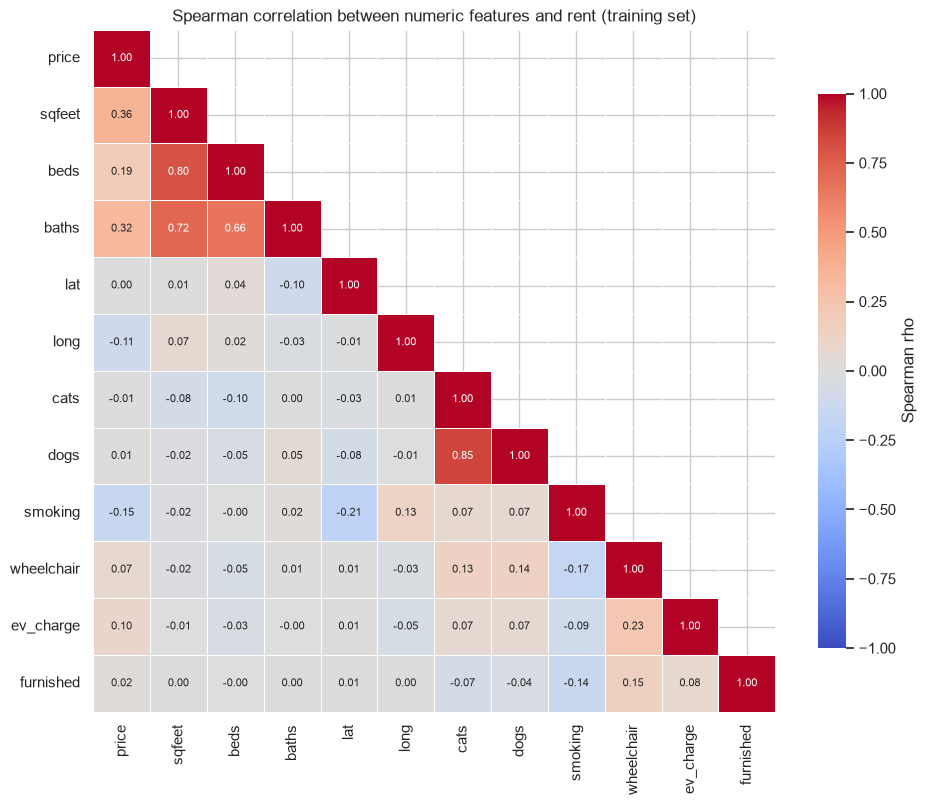

Strongly correlated feature pairs (|rho| >= 0.5):
  cats_allowed           & dogs_allowed           rho = +0.85
  sqfeet                 & beds                   rho = +0.80
  sqfeet                 & baths                  rho = +0.72
  beds                   & baths                  rho = +0.66

Correlation with rent, strongest first:
  sqfeet +0.36, baths +0.32, beds +0.19, smoking_allowed -0.15, long -0.11, electric_vehicle_charge +0.10, wheelchair_access +0.07, comes_furnished +0.02, dogs_allowed +0.01, cats_allowed -0.01, lat +0.00


In [2]:
# 10.1 Spearman correlation heatmap

corr_cols = ["price", "sqfeet", "beds", "baths", "lat", "long", *BINARY_COLS]
rho = train[corr_cols].corr(method="spearman")      # pairwise: blank coordinates are skipped pair by pair

short = {"electric_vehicle_charge": "ev_charge", "wheelchair_access": "wheelchair",
         "comes_furnished": "furnished", "smoking_allowed": "smoking",
         "cats_allowed": "cats", "dogs_allowed": "dogs"}
rho_plot = rho.rename(index=short, columns=short)
mask = np.triu(np.ones_like(rho_plot, dtype=bool), k=1)   # hide the repeated upper half

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(rho_plot, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, annot_kws={"size": 8},
            cbar_kws={"label": "Spearman rho", "shrink": 0.8}, ax=ax)
ax.set_title("Spearman correlation between numeric features and rent (training set)")
save_fig("10_spearman_heatmap")
plt.show()

feat = corr_cols[1:]                                   # features only, without price
pairs = pd.Series({(a, b): rho.loc[a, b] for i, a in enumerate(feat) for b in feat[i + 1:]})
strong_pairs = pairs[pairs.abs() >= 0.5].sort_values(key=abs, ascending=False)
print("Strongly correlated feature pairs (|rho| >= 0.5):")
if len(strong_pairs):
    for (a, b), v in strong_pairs.items():
        print(f"  {a:<22} & {b:<22} rho = {v:+.2f}")
else:
    print("  none")

with_price = rho["price"].drop("price").sort_values(key=abs, ascending=False)
print("\nCorrelation with rent, strongest first:")
print("  " + ", ".join(f"{k} {v:+.2f}" for k, v in with_price.items()))

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 10.1 Findings

**Strongly correlated pairs (|ρ| ≥ 0.5):**

| Pair | ρ | Meaning |
|---|---|---|
| `cats_allowed` & `dogs_allowed` | **+0.85** | landlords usually allow both pets or neither |
| `sqfeet` & `beds` | **+0.80** | bigger homes have more bedrooms |
| `sqfeet` & `baths` | **+0.72** | and more bathrooms |
| `beds` & `baths` | **+0.66** | the three size features partly repeat each other |

**Correlation with rent (strongest first):** `sqfeet` +0.36, `baths` +0.32, `beds` +0.19, `smoking_allowed` −0.15, `long` −0.11, `electric_vehicle_charge` +0.10, `wheelchair_access` +0.07; all others near 0.

**Smaller patterns worth knowing:**
- `wheelchair_access` & `electric_vehicle_charge` **+0.23**: both mark newer buildings, so they tend to appear together.
- `smoking_allowed` & `lat` **−0.21**: smoking is allowed more often in southern listings.
- **`lat` has ρ = 0.00 with rent, yet η² 7.1% in Step 9.** Spearman only detects links that *keep rising or falling*. Rent against latitude goes up and down (expensive Florida and California in the south, cheap Plains in the middle, expensive Northeast in the north), so a single ρ misses it. This is exactly why we also use η² and mutual information.

**Decision:** the pet flags overlap heavily and the size trio moderately. That's no problem for trees; for the linear model it's measured properly in 10.2.

## 10.2 How redundant are size, bedrooms and bathrooms? (VIF)

**The problem this section checks:** a linear model gives every feature a **coefficient**, its "price tag" (for example, *+4% rent per extra bathroom*). If two features almost always move together, the model can't tell which one deserves the credit. Many different combinations of coefficients then fit the data equally well, so the estimates become **unstable**: they swing when the data changes a little, and can even take the wrong sign. This is called **multicollinearity**.

> *Analogy:* two people always arrive together and carry a heavy box. You can see the box got carried, but you can't tell how much each person lifted. Give the model many examples where they arrive *separately*, and it can.

**The measure: Variance Inflation Factor (VIF).** For each feature:

1. Try to predict it from **all the other features** with a linear regression, and record how well that works (R², from 0 to 1).
2. VIF = 1 ÷ (1 − R²).

| R² from the others | VIF | Meaning |
|---|---|---|
| 0 | 1 | fully independent; no inflation |
| 0.50 | 2 | some overlap; harmless |
| 0.80 | **5** | moderate: coefficients noticeably less precise |
| 0.90 | **10** | severe: coefficients unreliable |

The name comes from what it measures: the uncertainty (variance) of that feature's coefficient is **inflated** by this factor compared with a feature that shares nothing with the others.

**What this cell does:**

1. **VIF for the size trio** (`log_sqfeet`, `beds`, `baths`), on the scale linear models will see.
2. **VIF for all numeric inputs** of the linear model together (the trio, coordinates and the six flags), using listings with coordinates.
3. **A coefficient check:** it fits a simple linear model of log rent on each size feature **alone**, and then on all three **together**, and compares the coefficients (shown as % change in rent for one standard deviation more of the feature). If a coefficient **shrinks a lot, or flips sign**, when the others are added, that's collinearity in action.

**How to read the coefficient check:** a sign flip for `beds` would not be a mistake. It would mean *"at the same floor space, one more bedroom means smaller rooms"*, and renters don't pay more for that. It shows that the one-at-a-time bedroom effect in Step 9 was mostly a **size** effect.

**Why this matters for our models:**

- **Ridge regression** (our linear model) adds a small penalty on large coefficients. That keeps the estimates stable when features overlap, instead of letting them swing to large opposite values. This is the evidence for choosing **Ridge over plain Linear Regression**.
- **Tree models** (Random Forest, LightGBM) don't estimate coefficients, so collinearity doesn't break them. It only splits their "feature importance" between the overlapping features, which matters when we interpret importances later.
- **k-NN and the MLP** are not affected in the same way, but redundant inputs count "size" twice in k-NN's distance. Standardisation (already planned) keeps that modest.

In [3]:
# 10.2 Variance Inflation Factor and a coefficient check

def vif_table(X):
    # VIF for each column: 1 / (1 - R^2) of predicting it from all the other columns
    Z = ((X - X.mean()) / X.std()).to_numpy(dtype=float)
    rows = {}
    for j, col in enumerate(X.columns):
        A = np.column_stack([np.ones(len(Z)), np.delete(Z, j, axis=1)])
        coef, *_ = np.linalg.lstsq(A, Z[:, j], rcond=None)
        r2 = 1 - np.var(Z[:, j] - A @ coef) / np.var(Z[:, j])
        rows[col] = {"R2_from_others": r2, "VIF": 1 / (1 - r2)}
    return pd.DataFrame(rows).T

size_trio = ["log_sqfeet", "beds", "baths"]
vif_size = vif_table(train[size_trio])
linear_inputs = ["log_sqfeet", "beds", "baths", "lat", "long", *BINARY_COLS]
vif_all = vif_table(train.loc[train["lat"].notna(), linear_inputs])

vif = vif_all.rename(columns={"R2_from_others": "R2 (all inputs)", "VIF": "VIF (all inputs)"})
vif = vif_size.rename(columns={"R2_from_others": "R2 (size trio)", "VIF": "VIF (size trio)"}).join(vif, how="right")
vif["level"] = np.select([vif["VIF (all inputs)"] >= VIF_SEVERE, vif["VIF (all inputs)"] >= VIF_MODERATE],
                         ["severe", "moderate"], default="fine")
vif = vif.sort_values("VIF (all inputs)", ascending=False)
display(vif.style.format({c: "{:.2f}" for c in vif.columns if c != "level"}, na_rep="-"))
max_vif, max_vif_col = vif["VIF (all inputs)"].max(), vif["VIF (all inputs)"].idxmax()
print(f"Highest VIF: {max_vif_col} = {max_vif:.2f}  (moderate from {VIF_MODERATE}, severe from {VIF_SEVERE})")

# Coefficient check: each size feature alone vs all three together
def std_coefs(cols):
    # Linear regression of log price on standardised features; returns coefficients in log-price units
    Z = (train[cols] - train[cols].mean()) / train[cols].std()
    A = np.column_stack([np.ones(len(Z)), Z.to_numpy(dtype=float)])
    coef, *_ = np.linalg.lstsq(A, train["log_price"].to_numpy(), rcond=None)
    return pd.Series(coef[1:], index=cols)

alone = pd.Series({c: std_coefs([c])[c] for c in size_trio})
together = std_coefs(size_trio)
coef_check = pd.DataFrame({"alone_%": pct(alone), "together_%": pct(together)})
coef_check["change"] = np.where(np.sign(alone) != np.sign(together), "sign flipped",
                                np.where(together.abs() < 0.5 * alone.abs(), "shrank by more than half", "similar"))
print("\n% change in rent for one standard deviation more of each feature:")
display(coef_check.style.format({"alone_%": "{:+.1f}%", "together_%": "{:+.1f}%"}))

,R2 (size trio),VIF (size trio),R2 (all inputs),VIF (all inputs),level
cats_allowed,-,-,0.73,3.72,fine
dogs_allowed,-,-,0.73,3.69,fine
log_sqfeet,0.67,3.02,0.67,3.07,fine
beds,0.64,2.76,0.64,2.81,fine
baths,0.50,1.99,0.52,2.08,fine
wheelchair_access,-,-,0.11,1.13,fine
smoking_allowed,-,-,0.10,1.12,fine
lat,-,-,0.07,1.08,fine
electric_vehicle_charge,-,-,0.06,1.07,fine
long,-,-,0.05,1.05,fine


Highest VIF: cats_allowed = 3.72  (moderate from 5, severe from 10)

% change in rent for one standard deviation more of each feature:


,alone_%,together_%,change
log_sqfeet,+18.2%,+23.8%,similar
beds,+9.6%,-11.7%,sign flipped
baths,+15.1%,+7.7%,similar


> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 10.2 Findings

**VIF – no worrying multicollinearity.** The highest VIF is **3.72** (`cats_allowed`; `dogs_allowed` 3.69), below the moderate level of 5. The size trio: `log_sqfeet` **3.07**, `beds` **2.81**, `baths` **2.08**. Coordinates and the other flags are close to 1 (independent).

**But the coefficient check shows collinearity at work:**

| Feature | Alone | Together | Change |
|---|---|---|---|
| `log_sqfeet` | +18.2% | **+23.8%** | similar (grows) |
| `beds` | +9.6% | **−11.7%** | **sign flipped** |
| `baths` | +15.1% | +7.7% | similar (about halves) |

(% change in rent for one standard deviation more of the feature.)

- **The bedroom sign flip is the key result.** On its own, more bedrooms means higher rent, because more bedrooms usually means a bigger home. But **at the same floor space**, one more bedroom means the space is cut into smaller rooms, and rent is **lower**. Part of that is also the per-bedroom student housing found in 10.7 (many bedrooms, low advertised rent).
- **Size carries the real effect:** once bedrooms and bathrooms are held constant, the size coefficient gets *larger*.
- A VIF below 5 doesn't mean "no problem". VIF measures how uncertain a coefficient is; the coefficient check shows that the *meaning* of a coefficient depends on which other features are in the model.

**Decision:** **Ridge** is used for the linear model (the penalty keeps overlapping coefficients stable, and the one-hot and encoded location columns add more overlap later). When interpreting any model, the effect of `beds` must be read as *"at the same size"*, never on its own.

> **Viva point:** "Beds alone raises rent 9.6% per standard deviation, but holding size and bathrooms constant it lowers rent 11.7%. That sign flip is a textbook example of why one-at-a-time relationships and multivariate coefficients answer different questions."

## 10.3 Which features carry information about rent? (mutual information)

**What this cell does:** it measures the **mutual information (MI)** between each of the 16 model features and log rent, and puts it next to Step 9's η² ranking.

**What mutual information is, in plain words:** *how much does knowing this feature reduce our uncertainty about rent?* It's 0 when the feature tells us nothing, and it grows the more the feature narrows down the likely rent. It's measured in **nats** (a unit of information, like bits but using the natural log). The exact number is less important than the **ranking**.

**How it differs from what we've used so far:**

| Measure | Captures |
|---|---|
| Pearson r | straight-line links only |
| Spearman ρ | any steadily rising or falling link |
| η² (Step 9) | differences between group averages |
| **Mutual information** | **any** kind of dependence, including curves, U-shapes and differences in *spread*, not just in average |

So MI is a second, independent opinion on the Step 9 ranking. If both methods agree, the ranking is trustworthy.

**How it's estimated:** scikit-learn's `mutual_info_regression` uses a **nearest-neighbour** method. For a continuous feature (size, coordinates), it looks at how close listings are to each other in the feature *and* in rent. Categories and counts are marked as **discrete**, so they're treated as labels (region codes have no order).

**Two practical details:**

1. **A fixed sample.** The estimator is slow on 150,000 rows, so it uses `MI_SAMPLE` = 40,000 listings chosen with `RANDOM_STATE` (only listings with coordinates, since the method can't handle blanks). That's plenty for a stable ranking.
2. **A chance baseline.** Features with many distinct values (like 413 regions) get a small MI above zero **even if they're unrelated to rent**, just by chance. To see how big that bias is, the cell also computes MI against a **shuffled** copy of rent, where every real link is destroyed. The **net MI** (real minus shuffled) is the fair number to rank on.

**How to read the output:** the chart shows net MI (left) and Step 9's η² (right) for every feature, in the same order. The printed **rank agreement** (a Spearman correlation between the two rankings) tells us how far the two methods agree: near 1 means the same ranking.

> **Viva point:** "We ranked features with two different methods, η² and mutual information. Mutual information can detect non-linear relationships that η² and correlation miss, and we corrected it for the chance bias of high-cardinality features with a shuffled-target baseline."

,MI,chance_MI,net_MI,eta2_%,MI_rank,eta2_rank
region_url,0.559,0.000,0.559,48.1%,1,1
long,0.491,0.000,0.491,22.4%,2,3
lat,0.377,0.000,0.377,7.1%,3,8
state,0.338,0.000,0.338,31.1%,4,2
sqfeet,0.305,0.000,0.305,14.4%,5,4
type,0.139,0.000,0.139,2.0%,6,11
laundry_options,0.121,0.000,0.121,10.8%,7,5
parking_options,0.108,0.003,0.105,10.2%,8,7
baths,0.103,0.001,0.102,10.8%,9,6
beds,0.089,0.000,0.089,4.6%,10,9


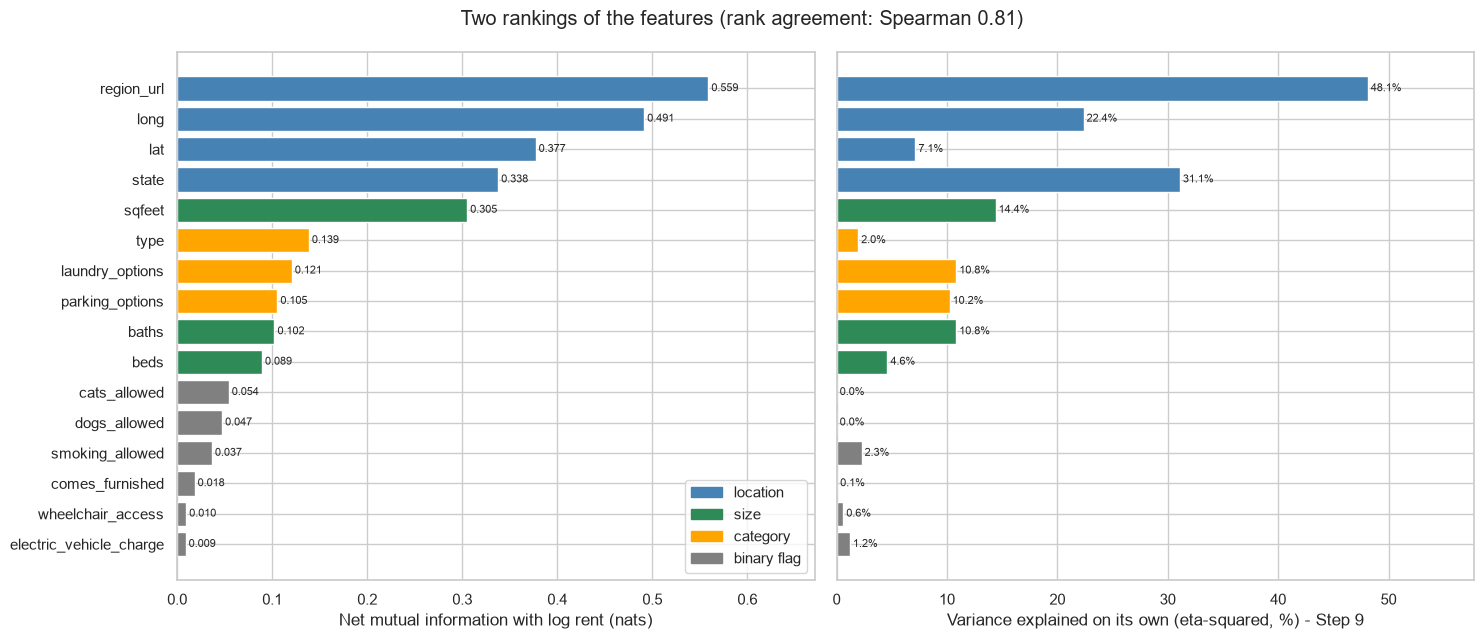

Rank agreement between net MI and eta-squared: 0.81
Features whose rank differs by 3+ places: lat (MI #3, eta2 #8), type (MI #6, eta2 #11), baths (MI #9, eta2 #6), cats_allowed (MI #11, eta2 #15), dogs_allowed (MI #12, eta2 #16), smoking_allowed (MI #13, eta2 #10), electric_vehicle_charge (MI #16, eta2 #12)


In [4]:
# 10.3 Mutual information with log price, compared with Step 9's eta-squared

mi_data = plot_sample(train[train["lat"].notna()], MI_SAMPLE)
X = pd.DataFrame(index=mi_data.index)
discrete = []
for col in MODEL_FEATURES:
    if col in ["sqfeet", "lat", "long"]:
        X[col] = mi_data[col].astype(float)
        discrete.append(False)
    else:                                              # categories, counts and flags are treated as labels
        X[col] = pd.factorize(mi_data[col])[0]
        discrete.append(True)
discrete = np.array(discrete)

y = mi_data["log_price"].to_numpy()
y_shuffled = np.random.default_rng(RANDOM_STATE).permutation(y)   # destroys every real link
mi_real = mutual_info_regression(X, y, discrete_features=discrete, random_state=RANDOM_STATE)
mi_base = mutual_info_regression(X, y_shuffled, discrete_features=discrete, random_state=RANDOM_STATE)

def grouping(col):
    # Same grouping as Step 9.8: measurements in 20 equal-sized bins, everything else by value
    if col in ["sqfeet", "lat", "long"]:
        return pd.qcut(train[col], 20, duplicates="drop").astype(str)
    return train[col].astype(str)

ranking = pd.DataFrame({"MI": mi_real, "chance_MI": mi_base}, index=MODEL_FEATURES)
ranking["net_MI"] = (ranking["MI"] - ranking["chance_MI"]).clip(lower=0)
ranking["eta2_%"] = [eta_squared(grouping(c)) * 100 for c in MODEL_FEATURES]
ranking["MI_rank"] = ranking["net_MI"].rank(ascending=False).astype(int)
ranking["eta2_rank"] = ranking["eta2_%"].rank(ascending=False).astype(int)
ranking = ranking.sort_values("net_MI", ascending=False)
display(ranking.style.format({"MI": "{:.3f}", "chance_MI": "{:.3f}", "net_MI": "{:.3f}", "eta2_%": "{:.1f}%"}))

rank_agreement = spearmanr(ranking["net_MI"], ranking["eta2_%"])[0]

kind = {**{c: "location" for c in ["region_url", "state", "lat", "long"]},
        **{c: "size" for c in ["sqfeet", "beds", "baths"]},
        **{c: "category" for c in ["type", "laundry_options", "parking_options"]},
        **{c: "binary flag" for c in BINARY_COLS}}
colors = {"location": "steelblue", "size": "seagreen", "category": "orange", "binary flag": "grey"}
order = ranking.index[::-1]
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)
for ax, colname, label in [(axes[0], "net_MI", "Net mutual information with log rent (nats)"),
                           (axes[1], "eta2_%", "Variance explained on its own (eta-squared, %) - Step 9")]:
    vals = ranking.loc[order, colname]
    ax.barh(order, vals, color=[colors[kind[c]] for c in order])
    for i, v in enumerate(vals):
        ax.text(v, i, f" {v:.3f}" if colname == "net_MI" else f" {v:.1f}%", va="center", fontsize=8)
    ax.set_xlim(0, vals.max() * 1.2)
    ax.set(xlabel=label)
axes[0].legend(handles=[Patch(color=c, label=k) for k, c in colors.items()], loc="lower right")
fig.suptitle(f"Two rankings of the features (rank agreement: Spearman {rank_agreement:.2f})")
plt.tight_layout()
save_fig("10_mutual_information_vs_eta2")
plt.show()

big_moves = ranking[(ranking["MI_rank"] - ranking["eta2_rank"]).abs() >= 3]
print(f"Rank agreement between net MI and eta-squared: {rank_agreement:.2f}")
print("Features whose rank differs by 3+ places: "
      + (", ".join(f"{c} (MI #{int(r.MI_rank)}, eta2 #{int(r.eta2_rank)})" for c, r in big_moves.iterrows()) or "none"))

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 10.3 Findings

**The two rankings broadly agree:** rank agreement (Spearman) **0.81**. Both put **location first and size next**:

| Net MI rank | Feature | Net MI | η² rank |
|---|---|---|---|
| 1 | `region_url` | 0.559 | 1 |
| 2 | `long` | 0.491 | 3 |
| 3 | `lat` | 0.377 | 8 |
| 4 | `state` | 0.338 | 2 |
| 5 | `sqfeet` | 0.305 | 4 |
| 6 | `type` | 0.139 | 11 |
| 7–10 | `laundry_options`, `parking_options`, `baths`, `beds` | 0.12–0.09 | 5, 7, 6, 9 |
| 11–16 | `cats`, `dogs`, `smoking`, `furnished`, `wheelchair`, `ev_charge` | 0.05–0.01 | 15, 16, 10, 14, 13, 12 |

**The chance baseline is almost zero for every feature** (at most 0.003), so the high-cardinality bias for `region_url` is negligible with 40,000 listings.

**Where the rankings differ, and why:**
- **`lat` (MI #3 vs η² #8) and `long`:** coordinates work *together*. A precise latitude plus longitude pins down the local market, and MI's nearest-neighbour method rewards that fine detail, while η² only sees 20 coarse bands of one coordinate at a time. This is evidence that **tree models, which can split on both coordinates, should use them well**.
- **`type` (MI #6 vs η² #11):** type changes the *shape* of the rent distribution (houses have a much wider spread than apartments, Step 9.3), not only its average. MI sees shape differences; η² sees only averages.
- **Pet flags (MI ≈ 0.05 vs η² 0.0%):** treat with caution. The nearest-neighbour estimator is sensitive to **repeated exact prices**: families of near-identical listings (Step 7: 37% of listings have a relative) share both the exact price and the same flags, which the estimator can read as "information". The weak features' MI values are probably inflated by this.

**Decision:** no feature is dropped. The final judgement on weak features comes from the models themselves (permutation importance in grouped cross-validation), not from any single EDA measure.

> **Viva point:** "We ranked features with η² and with mutual information corrected by a shuffled baseline. They agree at the top (location, then size). The disagreements are informative: coordinates carry more information in combination, and property type changes the spread of rents, not just the average."

## 10.4 Is the size effect hidden by location? (confounding)

**The puzzle from Step 9:**

- A 10% larger home rented for only about **4.5%** more (elasticity 0.45), which seems low.
- **Studios** had the same median rent as **1-bedroom** homes ($1,035 vs $1,029), even though they're smaller.

**The suspected reason is location.** Expensive markets (San Francisco, New York, Boston) have **small** homes, because space is scarce, and **high** rents. Cheap markets have **large** homes and **low** rents. When we compare all listings nationally, these two patterns partly cancel the true "bigger home, higher rent" effect. Studios, in particular, are a big-city product.

**What this cell does, in three parts:**

1. **Region-level check.** For each region, it takes the median size and the median rent, and plots one dot per region. If expensive regions really have smaller homes, the dots slope **downwards**, and the printed Spearman ρ across regions is **negative**.
2. **National vs within-region size effect.** It fits the size–rent slope twice:
   - **nationally**, on the raw log values (this reproduces Step 9's 0.45);
   - **within regions**, after subtracting each region's average from both log size and log rent (`region_demeaned`). Now every comparison is *inside one market*. Economists call this a **fixed-effects** estimate.
   It also reports how much of the **within-region** variation in rent size explains (R² within).
3. **Bedrooms, with and without location.** It plots the median rent per bedroom count twice: as observed (Step 9), and **region-adjusted**, meaning each listing's rent is expressed relative to its own region's average, then put back on the national level so it reads in dollars.

4. **The parking puzzle.** Step 9.3 found that listings with **no parking** had a *higher* median rent than listings with **off-street parking**. The same region-adjusted comparison is repeated for every parking option. If "no parking" drops below "off-street parking" once location is removed, the puzzle is explained: car-free homes are mostly in dense, expensive cities.

**How to read the output:**

- **Within-region slope clearly larger than the national slope** → location was hiding part of the size effect. The true "same-market" premium for space is larger than 4.5% per 10%.
- **Studio line below the 1-bedroom line once region-adjusted** → the studio puzzle is explained by location, not by anything strange about studios.

**Why this matters for the project:**

- It explains two odd-looking Step 9 results, which is a common viva question ("why do studios cost the same as 1-bedrooms?").
- It shows that **a model needs location and size together**. A model that knows the region can use the stronger within-market size effect. This is also why the platform must always ask for the region.
- For the report: **one-at-a-time relationships can mislead**. Only a model with all features (or a within-group analysis) gives each feature its fair effect.

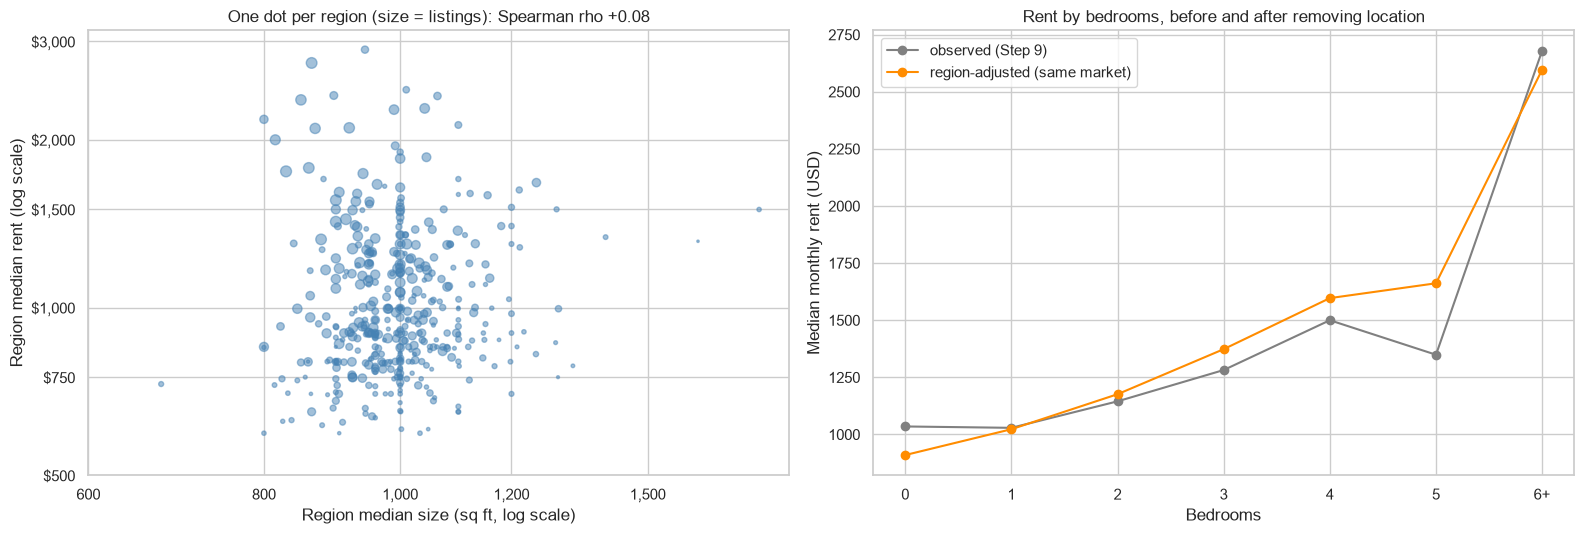

Across regions, median size vs median rent: Spearman rho = +0.08
Size elasticity nationally:     0.45  (R^2 0.145)
Size elasticity within regions: 0.49  (R^2 of what is left after location 0.322)
  -> within the same market, a 10% larger home rents for about 4.9% more (nationally 4.5%)


,listings,observed_median,region_adjusted_median
beds,,,
0,"4,347","$1,035",$910
1,"43,804","$1,029","$1,023"
2,"64,343","$1,145","$1,176"
3,"30,142","$1,282","$1,373"
4,"6,084","$1,500","$1,597"
5,"1,502","$1,349","$1,662"
6+,182,"$2,680","$2,597"


Studio vs 1-bedroom: +0.6% observed, -11.1% within the same region

Parking options, observed vs region-adjusted median rent (sorted by region-adjusted):


,listings,observed_median,region_adjusted_median
parking_options,,,
street parking,"6,816","$1,100","$1,078"
off-street parking,"49,138","$1,000","$1,095"
carport,"15,053","$1,240","$1,124"
missing,"47,399","$1,099","$1,136"
no parking,"1,092","$1,150","$1,147"
detached garage,"8,012","$1,300","$1,272"
attached garage,"22,786","$1,569","$1,457"
valet parking,108,"$1,894","$1,490"


'no parking' vs 'off-street parking': +15.0% observed, +4.8% within the same region


In [5]:
# 10.4 Location confounding of the size effect

# Part 1: do expensive regions have smaller homes?
region_stats = train.groupby("region_url").agg(listings=("price", "size"),
                                               med_log_price=("log_price", "median"),
                                               med_log_sqft=("log_sqfeet", "median"))
rho_regions = spearmanr(region_stats["med_log_sqft"], region_stats["med_log_price"])[0]

# Part 2: national vs within-region slope
national_slope = np.polyfit(train["log_sqfeet"], train["log_price"], 1)[0]
dem_sq, dem_price = region_demeaned("log_sqfeet"), region_demeaned("log_price")
within_slope = np.polyfit(dem_sq, dem_price, 1)[0]
r2_national = np.corrcoef(train["log_sqfeet"], train["log_price"])[0, 1] ** 2
r2_within = np.corrcoef(dem_sq, dem_price)[0, 1] ** 2

# Part 3: bedrooms, observed and region-adjusted
beds_grp = train["beds"].clip(upper=6).map(lambda v: "6+" if v >= 6 else str(int(v)))
beds_order = [v for v in [str(i) for i in range(6)] + ["6+"] if v in set(beds_grp)]
adj_price = np.expm1(dem_price + train["log_price"].mean())       # rent relative to own region, in dollars
beds_compare = pd.DataFrame({
    "listings": beds_grp.value_counts(),
    "observed_median": train["price"].groupby(beds_grp).median(),
    "region_adjusted_median": adj_price.groupby(beds_grp).median(),
}).loc[beds_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
sc = axes[0].scatter(region_stats["med_log_sqft"], region_stats["med_log_price"], s=np.sqrt(region_stats["listings"]) * 1.5,
                     alpha=0.5, color="steelblue")
axes[0].set_xticks(np.log1p([600, 800, 1000, 1200, 1500]))
axes[0].set_xticklabels(["600", "800", "1,000", "1,200", "1,500"])
dollar_axis(axes[0], ticks=[500, 750, 1000, 1500, 2000, 3000])
axes[0].set(xlabel="Region median size (sq ft, log scale)", ylabel="Region median rent (log scale)",
            title=f"One dot per region (size = listings): Spearman rho {rho_regions:+.2f}")

x = np.arange(len(beds_order))
axes[1].plot(x, beds_compare["observed_median"], marker="o", color="grey", label="observed (Step 9)")
axes[1].plot(x, beds_compare["region_adjusted_median"], marker="o", color="darkorange",
             label="region-adjusted (same market)")
axes[1].set_xticks(x); axes[1].set_xticklabels(beds_order)
axes[1].set(xlabel="Bedrooms", ylabel="Median monthly rent (USD)", title="Rent by bedrooms, before and after removing location")
axes[1].legend()
plt.tight_layout()
save_fig("10_location_confounding")
plt.show()

print(f"Across regions, median size vs median rent: Spearman rho = {rho_regions:+.2f}")
print(f"Size elasticity nationally:     {national_slope:.2f}  (R^2 {r2_national:.3f})")
print(f"Size elasticity within regions: {within_slope:.2f}  (R^2 of what is left after location {r2_within:.3f})")
print(f"  -> within the same market, a 10% larger home rents for about {within_slope * 10:.1f}% more "
      f"(nationally {national_slope * 10:.1f}%)")
display(beds_compare.style.format({"listings": "{:,}", "observed_median": "${:,.0f}", "region_adjusted_median": "${:,.0f}"}))

studio_gap_obs = (beds_compare.loc["0", "observed_median"] / beds_compare.loc["1", "observed_median"] - 1) * 100
studio_gap_adj = (beds_compare.loc["0", "region_adjusted_median"] / beds_compare.loc["1", "region_adjusted_median"] - 1) * 100
print(f"Studio vs 1-bedroom: {studio_gap_obs:+.1f}% observed, {studio_gap_adj:+.1f}% within the same region")

# Part 4: the parking puzzle from Step 9.3, with and without location
parking_compare = pd.DataFrame({
    "listings": train["parking_options"].value_counts(),
    "observed_median": train["price"].groupby(train["parking_options"]).median(),
    "region_adjusted_median": adj_price.groupby(train["parking_options"]).median(),
}).sort_values("region_adjusted_median")
print("\nParking options, observed vs region-adjusted median rent (sorted by region-adjusted):")
display(parking_compare.style.format({"listings": "{:,}", "observed_median": "${:,.0f}", "region_adjusted_median": "${:,.0f}"}))
if {"no parking", "off-street parking"} <= set(parking_compare.index):
    np_obs = (parking_compare.loc["no parking", "observed_median"] / parking_compare.loc["off-street parking", "observed_median"] - 1) * 100
    np_adj = (parking_compare.loc["no parking", "region_adjusted_median"] / parking_compare.loc["off-street parking", "region_adjusted_median"] - 1) * 100
    print(f"'no parking' vs 'off-street parking': {np_obs:+.1f}% observed, {np_adj:+.1f}% within the same region")
else:
    np_obs = np_adj = np.nan

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 10.4 Findings – confounding by location

**Part 1: expensive regions do *not* have smaller homes overall.** Across regions, median size and median rent are unrelated (**ρ = +0.08**). The chart shows why: the most expensive big metros (the large dots at the top) *do* have small homes (800–950 sq ft), but cheap regions have every size, so the overall correlation is near zero. **The hypothesis in the introduction was only partly right.**

**Part 2: the size effect barely changes within regions.** Elasticity **0.45 nationally → 0.49 within regions** (a 10% larger home rents for about **4.9%** more in the same market). So size was only slightly hidden by location.

The bigger result is the **R²**: nationally size explains **14.5%** of the variation in log rent; **within regions it explains 32.2%** of what's left. **Once location is known, size becomes a much stronger predictor.** Location and size work together, which is exactly what a multi-feature model exploits.

**Part 3: bedrooms – location *does* explain the Step 9 puzzles.**

| Beds | 0 | 1 | 2 | 3 | 4 | 5 | 6+ |
|---|---|---|---|---|---|---|---|
| Observed | $1,035 | $1,029 | $1,145 | $1,282 | $1,500 | **$1,349** | $2,680 |
| Same region | **$910** | $1,023 | $1,176 | $1,373 | $1,597 | **$1,662** | $2,597 |

- **Studios:** **+0.6%** vs 1-bedroom observed, **−11.1%** within the same region. Studios are cheaper, as expected, once we compare like with like. The observed tie came from studios being concentrated in expensive cities.
- **5 bedrooms:** the −10% dip **disappears** within regions ($1,662 > $1,597). The dip came from 5-bedroom homes being common in cheap markets, largely college towns (see 10.7).
- **Region-adjusted rent now rises steadily** with every extra bedroom.

**Part 4: parking.** "No parking" vs "off-street": **+15.0% observed → +4.8% within the same region**. About two-thirds of the puzzle is location (car-free homes are in expensive cities). The rest is probably location *within* a region (downtown vs suburb in the same Craigslist area). Valet parking's premium over off-street shrinks from +89% observed ($1,894 vs $1,000) to +36% within regions ($1,490 vs $1,095), and attached garages stay clearly at the top of the ordinary options.

**Log correction:** the first version of the 10.8 log said "expensive markets have smaller homes", which ρ = +0.08 doesn't support. The wording is now adaptive and describes what was actually found.

**Decision:** models must see **size, rooms and location together**; one-at-a-time comparisons (Step 9) are descriptive only, and the report should say so.

## 10.5 What does region add beyond state? And how should small regions be smoothed?

**Background:** Step 9 ranked `region_url` first (η² 48%) and `state` second (31%). Every region lies inside one state (Step 5.7 gave each Craigslist site a single state label), so the two are **nested**: once you know the region, you also know the state. Two questions follow.

**Question 1: how much does region add beyond state?** The cell splits the variation in log rent into three parts that **do** add up to 100% (unlike Step 9's separate η² values):

| Part | Computed as | Meaning |
|---|---|---|
| between states | η²(state) | what the state alone explains |
| between regions *within* a state | η²(region) − η²(state) | what region adds on top of state (e.g. New York City vs upstate New York) |
| within regions | 1 − η²(region) | what location can't explain: size, type, amenities, and noise |

This works because the categories are nested: the region averages already contain everything the state averages do.

**Question 2: what should a small region be pulled towards?** Target encoding (Step 8.5) replaces each region by its average rent, **smoothed**: a region with few listings is pulled towards a fallback value, because its own average is unreliable. scikit-learn's `TargetEncoder` pulls towards the **national** average. Step 9.7 found something unexpected: small regions are **not** randomly scattered around the national median. Most are **cheaper** (rural Craigslist sites). Pulling them towards the national average could push their encoded rent **up**, in the wrong direction.

A natural alternative is to pull each region towards its **own state's** average. The cell tests which fallback is closer to the truth:

- For each region, it compares the region's average log rent with (a) the **national** average and (b) its **state's** average **computed without that region's own listings** (otherwise the region would be helping to predict itself, which would flatter the state option).
- It reports the typical error of each fallback, in %, for small regions (fewer than 30 listings) and for all regions, and how often the state is the closer of the two.

**How to read the output:**

- A large "between regions within a state" share → region carries real information beyond state (keep it).
- The state fallback clearly closer than the national one → evidence for **state-level smoothing** (a design option to test when building `src/features.py`). Keeping `state` as its own one-hot feature next to the region encoding already lets every model make that correction itself; the check shows how much it matters.
- Regions that are the **only** region in their state (for example D.C.) have no "state without the region" value, so they're left out of this comparison.

> **Viva point:** "Region and state are nested. We decomposed the variance into between-state, between-region-within-state and within-region parts, and tested whether smoothing small regions towards their state is better than towards the national average."

Every region has exactly one state label: True  (0 regions with more than one)


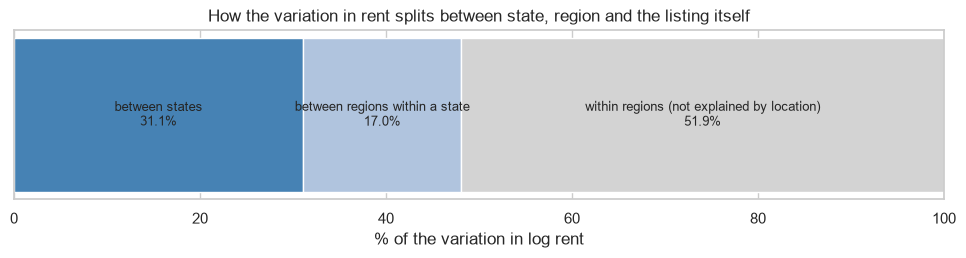

,regions,"typical error, national fallback","typical error, state fallback",state closer in % of regions,avg rent vs national
group,,,,,
regions with < 30 listings,29,44.0%,22.7%,83%,-29.0%
all regions,405,30.1%,18.3%,72%,-14.2%


Regions left out (only region in their state): 8


In [6]:
# 10.5 Region vs state: variance decomposition and the smoothing fallback

states_per_region = train.groupby("region_url")["state"].nunique()
nested = bool((states_per_region == 1).all())
print(f"Every region has exactly one state label: {nested}  "
      f"({int((states_per_region > 1).sum())} regions with more than one)")

eta_state = eta_squared(train["state"])
eta_region = eta_squared(train["region_url"])
decomp = pd.Series({"between states": eta_state,
                    "between regions within a state": eta_region - eta_state,
                    "within regions (not explained by location)": 1 - eta_region}) * 100

fig, ax = plt.subplots(figsize=(12, 2.2))
left = 0
for (label, v), c in zip(decomp.items(), ["steelblue", "lightsteelblue", "lightgrey"]):
    ax.barh([0], [v], left=left, color=c, edgecolor="white")
    ax.text(left + v / 2, 0, f"{label}\n{v:.1f}%", ha="center", va="center", fontsize=9)
    left += v
ax.set(xlim=(0, 100), yticks=[], xlabel="% of the variation in log rent")
ax.set_title("How the variation in rent splits between state, region and the listing itself")
save_fig("10_region_state_decomposition")
plt.show()

# Smoothing fallback: national average vs the state's average without the region itself
reg = train.groupby("region_url").agg(state=("state", "first"), n=("log_price", "size"),
                                      total=("log_price", "sum"), mean=("log_price", "mean"))
st = train.groupby("state")["log_price"].agg(["sum", "size"])
rest_n = reg["state"].map(st["size"]) - reg["n"]
reg["state_mean_without_region"] = (reg["state"].map(st["sum"]) - reg["total"]) / rest_n.where(rest_n > 0)
reg["err_national"] = (reg["mean"] - train["log_price"].mean()).abs()
reg["err_state"] = (reg["mean"] - reg["state_mean_without_region"]).abs()
comparable = reg.dropna(subset=["state_mean_without_region"])

rows = []
for label, part in [("regions with < 30 listings", comparable[comparable["n"] < 30]),
                    ("all regions", comparable)]:
    rows.append({"group": label, "regions": len(part),
                 "typical error, national fallback": pct(part["err_national"].median()),
                 "typical error, state fallback": pct(part["err_state"].median()),
                 "state closer in % of regions": (part["err_state"] < part["err_national"]).mean() * 100,
                 "avg rent vs national": pct(part["mean"].mean() - train["log_price"].mean())})
fallback = pd.DataFrame(rows).set_index("group")
display(fallback.style.format({"regions": "{:,}", "typical error, national fallback": "{:.1f}%",
                               "typical error, state fallback": "{:.1f}%",
                               "state closer in % of regions": "{:.0f}%", "avg rent vs national": "{:+.1f}%"}))
print(f"Regions left out (only region in their state): {len(reg) - len(comparable)}")

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 10.5 Findings – region vs state

- **Nested:** every region has exactly one state label (0 exceptions).
- **How the variation in log rent splits:**

| Part | Share |
|---|---|
| between states | **31.1%** |
| between regions within a state | **17.0%** |
| within regions (size, type, amenities, noise) | **51.9%** |

  Region adds **17 percentage points** beyond state: a lot of the location effect is *inside* states (NYC vs upstate, coastal vs inland California). **About half of all variation is within regions**, which is what the non-location features and the model have to explain.

**The smoothing fallback – a clear result:**

| | Regions | Typical error, national fallback | Typical error, state fallback | State closer | Avg rent vs national |
|---|---|---|---|---|---|
| Regions with < 30 listings | 29 | 44.0% | **22.7%** | **83%** | −29.0% |
| All regions | 405 | 30.1% | **18.3%** | **72%** | −14.2% |

- For small regions, the **state average is about twice as close** to the region's true rent as the national average, and it's the better guess for **83%** of them.
- Small regions are on average **29% cheaper** than the national level, confirming Step 9.7: pulling them towards the national average would push their predictions **up**.
- 8 regions were left out because they are the only region in their state.

**Decision:** keep **both** `region_url` (target-encoded) and `state` (one-hot). For the region encoding, build and test a **state-prior** version in `src/features.py`: each small region is shrunk towards **its own state's average** instead of the national one. It'll be compared with sklearn's default `TargetEncoder` in grouped cross-validation, and the better one is kept.

> **Viva point:** "Smoothing needs a fallback. We showed that for small regions, the state average is twice as accurate as the national average, so we use a hierarchical, state-level prior."

## 10.6 Does the effect of one feature depend on another? (interaction checks)

**The idea:** a linear model assumes each feature adds the **same** amount everywhere. For example, *"10% more space → 4.5% more rent"* in every state. If the real effect **varies**, that's an **interaction**. Tree models (Random Forest, LightGBM) and the MLP discover interactions on their own; a linear model only captures them if we build interaction columns by hand. So this section is **evidence for the model comparison**: the more interaction we find, the more we expect the flexible models to beat Ridge.

**Check A – the size effect in each of the 10 largest states.** For each state, it computes the **within-region** size elasticity (as in 10.4, so location differences between regions don't blur it) and draws one bar per state, sorted by the state's median rent. The dashed line is the national within-region elasticity from 10.4.

- **Bars of similar height** → size has a similar effect everywhere; a linear model is fine for size.
- **Bars that differ a lot**, especially rising with the state's rent level → space is worth relatively more in expensive markets: an interaction between size and location.
- The printed Spearman ρ shows whether elasticity rises with the state's median rent.

**Check B – price per square foot by property type, within the 5 largest states** (from the EDA plan). Rent per square foot removes the size difference between types, so we compare what each **type** is worth per unit of space. The heatmap shows the median $/sq ft for each type (rows, cheapest nationally at the top) in each state (columns). Cells with fewer than `MIN_CELL` = 30 listings are left blank.

- **If the type ranking is the same in every column**, type adds roughly the same premium everywhere (no interaction).
- **If the order changes between states** (for example condos top in one state, houses in another), type and location interact.
- The printed **type-rank agreement** is the average Spearman correlation between each state's type ranking and the national ranking: near 1 means "same order everywhere".

> **Viva point:** "We found [little / clear] evidence of interactions, which [supports a simple linear baseline / explains why tree-based models are expected to outperform Ridge]." Fill this in from the output in the findings cell below.

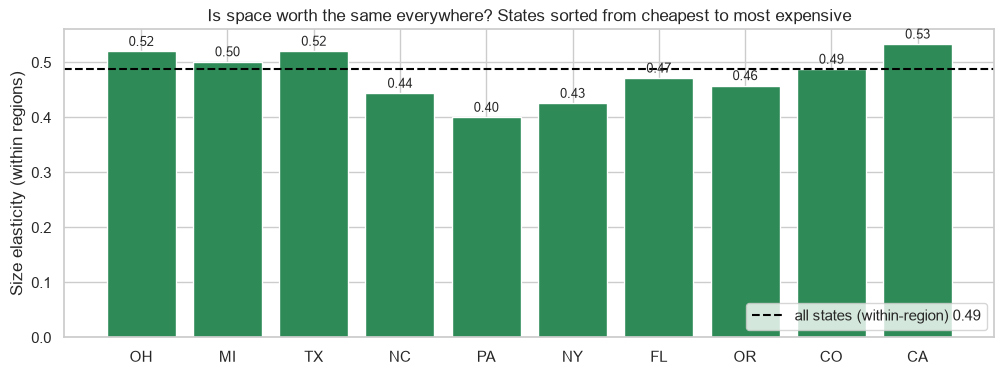

Size elasticity across the 10 largest states: 0.40 (PA) to 0.53 (CA)
Does elasticity rise with the state's median rent? Spearman rho = -0.04


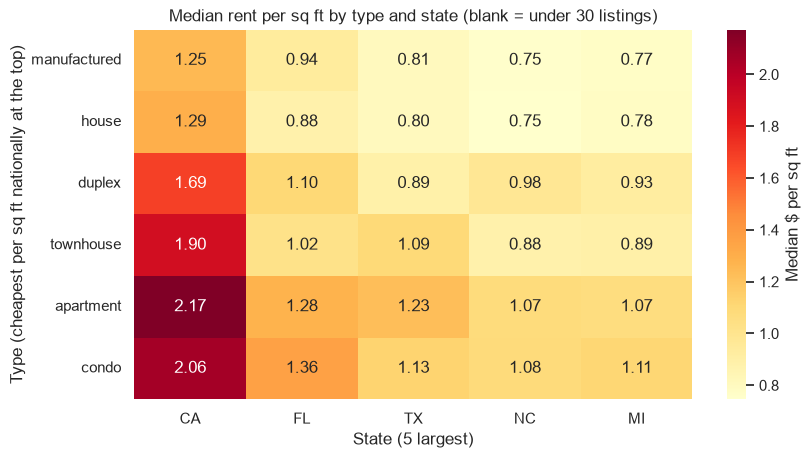

Type-rank agreement with the national order (average Spearman over states): 0.91


In [7]:
# 10.6 Interaction checks

# Check A: within-region size elasticity by state (10 largest states)
top_states = train["state"].value_counts().head(10).index
state_median = train.groupby("state")["price"].median()
slopes = {}
for s in top_states:
    m = train["state"] == s
    slopes[s] = np.polyfit(dem_sq[m], dem_price[m], 1)[0]
slopes = pd.Series(slopes).loc[state_median.loc[top_states].sort_values().index]
slope_vs_rent = spearmanr(slopes.values, state_median.loc[slopes.index].values)[0]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(slopes.index.str.upper(), slopes.values, color="seagreen")
for i, (s, v) in enumerate(slopes.items()):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
ax.axhline(within_slope, color="black", linestyle="--", label=f"all states (within-region) {within_slope:.2f}")
ax.set(ylabel="Size elasticity (within regions)",
       title="Is space worth the same everywhere? States sorted from cheapest to most expensive")
ax.legend(loc="lower right")
save_fig("10_size_elasticity_by_state")
plt.show()
print(f"Size elasticity across the 10 largest states: {slopes.min():.2f} ({slopes.idxmin().upper()}) "
      f"to {slopes.max():.2f} ({slopes.idxmax().upper()})")
print(f"Does elasticity rise with the state's median rent? Spearman rho = {slope_vs_rent:+.2f}")

# Check B: price per sq ft by type within the 5 largest states
top5 = train["state"].value_counts().head(5).index
sub = train[train["state"].isin(top5)].assign(ppsf=lambda d: d["price"] / d["sqfeet"])
ppsf_tab = sub.groupby(["type", "state"])["ppsf"].median().unstack()
ppsf_n = sub.groupby(["type", "state"]).size().unstack().reindex_like(ppsf_tab)
ppsf_tab = ppsf_tab.where(ppsf_n >= MIN_CELL)
national_type_order = (train["price"] / train["sqfeet"]).groupby(train["type"]).median().sort_values()
ppsf_tab = ppsf_tab.reindex([t for t in national_type_order.index if t in ppsf_tab.index])
ppsf_tab = ppsf_tab[ppsf_tab.notna().sum(axis=1) >= 2][list(top5)]

fig, ax = plt.subplots(figsize=(9, 0.55 * len(ppsf_tab) + 1.5))
sns.heatmap(ppsf_tab, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={"label": "Median $ per sq ft"}, ax=ax)
ax.set_xticklabels([s.upper() for s in ppsf_tab.columns])
ax.set(xlabel="State (5 largest)", ylabel="Type (cheapest per sq ft nationally at the top)",
       title=f"Median rent per sq ft by type and state (blank = under {MIN_CELL} listings)")
save_fig("10_ppsf_type_by_state")
plt.show()

type_rank_rhos = []
for s in ppsf_tab.columns:
    col = ppsf_tab[s].dropna()
    if len(col) >= 3:
        type_rank_rhos.append(spearmanr(col.values, national_type_order.loc[col.index].values)[0])
type_rank_agreement = float(np.mean(type_rank_rhos)) if type_rank_rhos else np.nan
print(f"Type-rank agreement with the national order (average Spearman over states): {type_rank_agreement:.2f}")

> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 10.6 Findings – interactions

**Check A – is space worth the same everywhere?** Within-region size elasticity in the 10 largest states ranges from **0.40 (Pennsylvania) to 0.53 (California)**, around the national 0.49. The range (0.13) is small, and it **doesn't rise with the state's rent level** (ρ = −0.04; cheap Ohio and Texas are at 0.52, like California). **No meaningful size × location interaction.**

**Check B – type premium by state** (median $/sq ft, 5 largest states):

| Type | CA | FL | TX | NC | MI |
|---|---|---|---|---|---|
| manufactured | 1.25 | 0.94 | 0.81 | 0.75 | 0.77 |
| house | 1.29 | 0.88 | 0.80 | 0.75 | 0.78 |
| duplex | 1.69 | 1.10 | 0.89 | 0.98 | 0.93 |
| townhouse | 1.90 | 1.02 | 1.09 | 0.88 | 0.89 |
| apartment | **2.17** | 1.28 | 1.23 | 1.07 | 1.07 |
| condo | 2.06 | 1.36 | 1.13 | 1.08 | 1.11 |

- **The order of types is almost the same in every state** (type-rank agreement **0.91**): apartments and condos cost the most per sq ft, houses and manufactured homes the least. (Apartments are dear *per sq ft* because they are small, and the size elasticity below 1 means small homes cost more per square foot.)
- **California costs almost twice as much per sq ft** for every type. That's a **multiplication**, and on the log scale the models use, a multiplication becomes a simple **addition**. This is another reason the log target suits the data: the location effect becomes the same shift for every type.
- The **size** of the apartment-vs-house gap varies a little (about +68% in California vs +37% in Michigan), a mild interaction that trees can pick up.

**Decision:** interactions are **modest**. **Ridge should be a competitive baseline**, and gains from Random Forest, LightGBM and the MLP will come mostly from finer location detail (coordinates, 10.3) and non-linear patterns such as per-bedroom pricing (10.7), rather than from large interactions.

## 10.7 Are some large homes priced per bedroom? (student-housing check)

**Why this check exists:** two results in Step 9.2 didn't fit the "bigger home, higher rent" pattern:

- **5-bedroom** homes had a *lower* median rent than 4-bedroom homes (−10%).
- **4-bathroom** homes had a very **wide** box reaching down to about $600, lower than 3.5-bathroom homes.

A likely explanation is **purpose-built student housing**. Near universities, apartments with (for example) 4 bedrooms and 4 bathrooms are often **leased per bedroom**: each student signs for one room with its own bathroom. The Craigslist listing then shows the **whole apartment's** size and room counts, but the **price of one bedroom**. That's the same "per-room pricing" problem that Step 5.4 found in a few listings, but hidden inside plausible-looking numbers.

**What this cell does:**

1. It takes homes with **3 to 5 bedrooms** and splits them into two groups: **one bathroom per bedroom (or more)** (`baths ≥ beds`, the typical student layout) and **fewer bathrooms than bedrooms** (the typical family home).
2. For each bedroom count and group, it shows the number of listings, the median rent, the median **rent per square foot** and the median **rent per bedroom**.
3. If the listing text is in the training file, it measures how often each group's description contains **per-bedroom wording** ("per bed", "per person", "individual lease", "by the bed"…). This is direct evidence, not just a pattern in the numbers.
4. It lists the regions where **one-bath-per-bedroom** homes with a very low rent per square foot (below the national 10th percentile) are most common. College towns in that list support the student-housing explanation.

**How to read the output:** in normal housing, *more* bathrooms for the same number of bedrooms means a **higher** rent. So if the "one bath per bedroom" group is **cheaper** than the "fewer baths" group, especially per square foot, and its descriptions mention per-bedroom leases much more often, per-bedroom pricing is the likely cause.

**What we will (and won't) do about it:**

- **No new cleaning rule now.** All cleaning rules were applied *before* the train/test split (Step 7). Changing them now would mean re-running the split, and the test set would no longer be the one we locked. Instead, the finding is recorded as a **data limitation**.
- **Step 11 (error analysis)** will check whether the models make their largest errors on these listings. That's the right place to quantify the damage.
- For the report: it's a good example of a **hidden data-quality issue** that only appears when two features are looked at together.

In [8]:
# 10.7 Per-bedroom pricing check (3-5 bedroom homes)

multi = train[train["beds"].between(3, 5)].copy()
multi["layout"] = np.where(multi["baths"] >= multi["beds"], "one bath per bedroom", "fewer baths than bedrooms")
multi["ppsf"] = multi["price"] / multi["sqfeet"]
multi["rent_per_bedroom"] = multi["price"] / multi["beds"]

layout_tab = multi.groupby(["beds", "layout"]).agg(listings=("price", "size"), median_rent=("price", "median"),
                                                   median_ppsf=("ppsf", "median"),
                                                   median_rent_per_bedroom=("rent_per_bedroom", "median"))
layout_tab = layout_tab[layout_tab["listings"] >= MIN_CELL]
display(layout_tab.style.format({"listings": "{:,}", "median_rent": "${:,.0f}", "median_ppsf": "${:.2f}",
                                 "median_rent_per_bedroom": "${:,.0f}"}))

# Is the "one bath per bedroom" group cheaper per sq ft at the same bedroom count?
ppsf_gap = {}
for b in [3, 4, 5]:
    if (b, "one bath per bedroom") in layout_tab.index and (b, "fewer baths than bedrooms") in layout_tab.index:
        ppsf_gap[b] = (layout_tab.loc[(b, "one bath per bedroom"), "median_ppsf"]
                       / layout_tab.loc[(b, "fewer baths than bedrooms"), "median_ppsf"] - 1) * 100
print("Rent per sq ft, one-bath-per-bedroom vs fewer-baths homes: "
      + (", ".join(f"{b} beds {g:+.1f}%" for b, g in ppsf_gap.items()) or "not enough listings"))

# Text evidence, if the description is in the training file
PER_BED = r"per bed|per bedroom|per person|per student|individual lease|by the bed|per room"
if "description" in multi.columns:
    has_wording = multi["description"].fillna("").str.contains(PER_BED, case=False, regex=True)
    wording_share = has_wording.groupby(multi["layout"]).mean() * 100
    print("Descriptions with per-bedroom wording: "
          + ", ".join(f"{k} {v:.1f}%" for k, v in wording_share.items()))
else:
    wording_share = None
    print("No description column in the training file: text evidence skipped")

# Where are the suspicious listings?
low_ppsf = (train["price"] / train["sqfeet"]).quantile(0.10)
suspects = multi[(multi["layout"] == "one bath per bedroom") & (multi["ppsf"] < low_ppsf)]
print(f"\nOne-bath-per-bedroom homes (3-5 beds) below the national 10th percentile of $/sq ft (${low_ppsf:.2f}): "
      f"{len(suspects):,} ({len(suspects) / len(train) * 100:.2f}% of training listings)")
if len(suspects):
    top_regions = suspects["region_url"].value_counts().head(10)
    top_regions.index = top_regions.index.str.replace("https://", "").str.replace(".craigslist.org", "")
    display(top_regions.rename("suspect listings").to_frame())

Rent per sq ft, one-bath-per-bedroom vs fewer-baths homes: 3 beds -7.3%, 4 beds -37.3%, 5 beds -34.2%
Descriptions with per-bedroom wording: fewer baths than bedrooms 1.9%, one bath per bedroom 7.6%

One-bath-per-bedroom homes (3-5 beds) below the national 10th percentile of $/sq ft ($0.71): 876 (0.58% of training listings)


,suspect listings
region_url,
gainesville,53
sanmarcos,48
tallahassee,34
tippecanoe,16
chambana,14
collegestation,14
tuscaloosa,13
batonrouge,12
desmoines,11


> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 10.7 Findings – per-bedroom pricing (student housing)

| Beds | Layout | Listings | Median rent | $/sq ft | Rent per bedroom |
|---|---|---|---|---|---|
| 3 | fewer baths than bedrooms | 28,212 | $1,275 | $0.96 | $425 |
| 3 | one bath per bedroom | 1,930 | $1,500 | $0.89 | $500 |
| 4 | fewer baths than bedrooms | 5,686 | $1,500 | $0.84 | $375 |
| 4 | **one bath per bedroom** | **398** | **$830** | **$0.53** | **$207** |
| 5 | fewer baths than bedrooms | 1,463 | $1,349 | $0.75 | $270 |
| 5 | **one bath per bedroom** | **39** | **$1,000** | **$0.49** | **$200** |

**The hypothesis is confirmed for 4 and 5 bedrooms**, with three independent kinds of evidence:
1. **Numbers:** a 4-bed/4-bath home "rents" for **$830**, *less than half* a 4-bed home with fewer bathrooms, and **37% less per sq ft** (5 beds: −34%). In normal housing, extra bathrooms raise rent. $830 for a whole 4-bed/4-bath home is implausible; **$207 per bedroom** is a plausible *room* price.
2. **Text:** per-bedroom wording ("per bed", "individual lease", …) appears **4× as often** (**7.6%** vs 1.9%) in one-bath-per-bedroom listings.
3. **Places:** the 876 suspect listings (**0.58%** of training listings) concentrate in **university towns**: Gainesville (Univ. of Florida), San Marcos (Texas State), Tallahassee (Florida State), Tippecanoe (Purdue), Champaign-Urbana (Illinois), College Station (Texas A&M), Tuscaloosa (Alabama), Baton Rouge (LSU), Lansing (Michigan State), Des Moines.

3-bed/3-bath homes are *not* affected (dearer than other 3-beds, only 7% lower per sq ft).

**Decision:**
- **No cleaning rule now.** The rules were frozen before the train/test split; changing them would mean re-splitting and a new test set. It's recorded as a **data limitation**: for 4+ bedroom homes with one bath per bedroom, the "price" is often **one room's** rent.
- **Step 11 error analysis** tracks this group separately.
- **A feature idea for `src/features.py`:** an indicator for "4+ bedrooms with a bathroom per bedroom", computed only from beds and baths (so it's available at prediction time and has no leakage). Trees can learn this pattern on their own; Ridge can't, so the indicator gives the linear model a fair chance.
- For the platform: warn users that predictions for 4+ bed/bath homes in college towns may reflect per-room prices.

> **Viva point:** "Combining beds and baths uncovered a hidden data-quality issue: in college towns, 4-bed/4-bath apartments are advertised at the price of one room. We confirmed it with price per square foot, description wording and location, and handled it as a documented limitation because cleaning rules were frozen before the split."

## 10.8 Log the Step 10 observations

As in every earlier step, `clear_obs("10")` removes older Step 10 entries, and every sentence is built from **your** results with if/else wording (for example, whether any VIF crossed the warning level, or whether the state fallback beat the national one). So the log always matches the output above, and nothing needs editing by hand.

**Before running this cell, check that `utils.py` has the corrected `clear_obs` / `show_obs`** (they must compare the step *number*, not the first characters). With the old version, re-running notebook 01 (`clear_obs("1")`) would also delete the Step 10–13 entries, because "10" starts with "1".

The interpretation for the report goes into the **findings cell at the end of this notebook** and into `reports/eda_findings.md`.

In [9]:
# 10.8 Log the observations

STEP = "10-Multivariate"
clear_obs("10")

log_obs(STEP,
        "Strongly correlated feature pairs (|Spearman| >= 0.5): "
        + (", ".join(f"{a} & {b} {v:+.2f}" for (a, b), v in strong_pairs.items()) if len(strong_pairs) else "none"),
        "10.1 Spearman heatmap",
        "Overlapping features are handled by Ridge (linear) and do not harm tree models; importances of "
        "correlated features must be read together")

log_obs(STEP,
        f"Highest VIF {max_vif:.2f} ({max_vif_col}); size trio VIFs "
        + ", ".join(f"{c} {v:.2f}" for c, v in vif_size["VIF"].items())
        + ("; coefficient check: " + ", ".join(f"{c} {r['change']}" for c, r in coef_check.iterrows())),
        "10.2 VIF table and coefficient check",
        ("Severe" if max_vif >= VIF_SEVERE else "Moderate" if max_vif >= VIF_MODERATE else "No worrying")
        + " multicollinearity among numeric inputs; "
        + ("Ridge (penalised) regression is required for the linear model"
           if max_vif >= VIF_MODERATE or (coef_check["change"] != "similar").any()
           else "Ridge is kept as the linear model because one-hot and encoded location columns add further overlap"))

log_obs(STEP,
        "Net mutual information top 3: " + ", ".join(f"{c} {v:.3f}" for c, v in ranking["net_MI"].head(3).items())
        + f"; rank agreement with eta-squared {rank_agreement:.2f}",
        "10.3 mutual information vs eta-squared chart",
        ("Two independent methods agree on the feature ranking; " if rank_agreement >= 0.8 else
         "The two methods rank some features differently (non-linear effects); ")
        + "no feature is dropped at this stage")

log_obs(STEP,
        f"Size elasticity {national_slope:.2f} nationally vs {within_slope:.2f} within regions; "
        f"region median size vs rent rho {rho_regions:+.2f}; studio vs 1-bed {studio_gap_obs:+.1f}% observed, "
        f"{studio_gap_adj:+.1f}% within region; no parking vs off-street {np_obs:+.1f}% observed, {np_adj:+.1f}% within region",
        "10.4 region scatter, bedroom lines, parking table",
        ("Size effect grows within regions" if within_slope > national_slope + 0.03
         else "Size effect barely changes within regions")
        + (" and region size/rent are linked" if abs(rho_regions) >= 0.3 else
           " (region median size and rent are unrelated overall)")
        + "; studio result " + ("explained by location" if abs(studio_gap_adj - studio_gap_obs) >= 5
                                  else "not a location effect")
        + "; parking result " + ("mostly explained by location" if abs(np_adj) < abs(np_obs) / 2
                                 else "only partly explained by location")
        + "; models must see size, rooms and location together")

log_obs(STEP,
        f"Variance of log rent: {decomp.iloc[0]:.1f}% between states, {decomp.iloc[1]:.1f}% between regions within "
        f"states, {decomp.iloc[2]:.1f}% within regions; small-region fallback error national "
        f"{fallback.iloc[0, 1]:.1f}% vs state {fallback.iloc[0, 2]:.1f}%",
        "10.5 decomposition bar, fallback table",
        "Keep region_url (target-encoded) and state (one-hot); "
        + ("smoothing towards the state average fits small regions better than the national average - "
           "test a state-prior encoder in src/features.py" if fallback.iloc[0, 2] < fallback.iloc[0, 1] else
           "the national fallback is adequate for small regions (default TargetEncoder)"))

log_obs(STEP,
        f"Within-region size elasticity by state {slopes.min():.2f}-{slopes.max():.2f} "
        f"(rho with state rent {slope_vs_rent:+.2f}); type-rank agreement across top-5 states {type_rank_agreement:.2f}",
        "10.6 elasticity bars, type x state heatmap",
        ("Size effect varies clearly by state (range > 0.2); " if slopes.max() - slopes.min() > 0.2
         else "Size effect is similar across states; ")
        + ("type premium order changes between states (agreement < 0.7); " if type_rank_agreement < 0.7
           else "type premium order is stable across states; ")
        + ("interactions exist: evidence for tree models and MLP over Ridge"
           if (slopes.max() - slopes.min() > 0.2 or type_rank_agreement < 0.7)
           else "interactions are modest: Ridge should be a competitive baseline"))

cheaper_student = [b for b, g in ppsf_gap.items() if g < 0]
log_obs(STEP,
        "Rent per sq ft of one-bath-per-bedroom vs fewer-baths homes: "
        + (", ".join(f"{b} beds {g:+.1f}%" for b, g in ppsf_gap.items()) or "n/a")
        + (f"; per-bedroom wording {wording_share.get('one bath per bedroom', np.nan):.1f}% vs "
           f"{wording_share.get('fewer baths than bedrooms', np.nan):.1f}%" if wording_share is not None else "")
        + f"; {len(suspects):,} suspect listings",
        "10.7 layout table, wording share, region list",
        ("Some large homes appear to be priced per bedroom (student housing): record as a data limitation; "
         "no rule change after the split; check model errors on them in Step 11"
         if cheaper_student else
         "No sign of per-bedroom pricing in large homes; no action"))

show_obs(10)

,step,observation,evidence,decision
0,10-Multivariate,Strongly correlated feature pairs (|Spearman| ...,10.1 Spearman heatmap,Overlapping features are handled by Ridge (lin...
1,10-Multivariate,Highest VIF 3.72 (cats_allowed); size trio VIF...,10.2 VIF table and coefficient check,No worrying multicollinearity among numeric in...
2,10-Multivariate,Net mutual information top 3: region_url 0.559...,10.3 mutual information vs eta-squared chart,Two independent methods agree on the feature r...
3,10-Multivariate,Size elasticity 0.45 nationally vs 0.49 within...,"10.4 region scatter, bedroom lines, parking table",Size effect grows within regions (region media...
4,10-Multivariate,"Variance of log rent: 31.1% between states, 17...","10.5 decomposition bar, fallback table",Keep region_url (target-encoded) and state (on...
5,10-Multivariate,Within-region size elasticity by state 0.40-0....,"10.6 elasticity bars, type x state heatmap",Size effect is similar across states; type pre...
6,10-Multivariate,Rent per sq ft of one-bath-per-bedroom vs fewe...,"10.7 layout table, wording share, region list",Some large homes appear to be priced per bedro...


> 📌 **Findings – what our data showed** (written after reviewing the run outputs)


### 10.8 Note on the log

The 10.4 entry was re-worded (see the 10.4 findings). **Restart & Run All** once so `observations_log.csv` gets the corrected sentence; none of the numbers change.

---

## Step 10 findings – what our data showed

1. **Redundancy:** size, beds and baths overlap (ρ 0.66–0.80) and cats/dogs strongly (0.85), but **no VIF reaches 5** (max 3.72). Still, the **bedroom coefficient flips sign** once size is held constant (+9.6% alone → −11.7% together). → **Ridge** for the linear model; read `beds` as "at the same size".
2. **Feature ranking confirmed:** mutual information and η² agree (rank agreement 0.81): location first, size second. Coordinates carry more information together than one at a time (latitude jumps from #8 to #3). No feature is dropped.
3. **Confounding:** location explains the Step 9 puzzles for **studios** (+0.6% → −11.1% vs 1-bed within region), **5 bedrooms** (dip disappears) and most of the **parking** puzzle (+15.0% → +4.8%). The size effect itself changes little (0.45 → 0.49), but within regions size explains **32%** of what's left (14.5% nationally).
4. **Region vs state:** 31.1% of variation is between states, **17.0%** between regions within states, 51.9% within regions. For small regions the **state average is twice as accurate as the national one** (22.7% vs 44.0% error) → test a **state-prior** region encoding.
5. **Interactions are modest:** size elasticity 0.40–0.53 across states with no trend; type order stable (0.91). → Ridge is a fair baseline.
6. **Per-bedroom pricing confirmed** in 4–5 bed homes with a bath per bedroom (median $830, $0.53/sq ft, per-bed wording 4× more common, college towns). 876 listings (0.58%). → **limitation**, error-analysis group, optional indicator feature.

**Decisions for the pipeline (`src/features.py`, later):**

| Decision | Evidence |
|---|---|
| Ridge, not plain linear regression | 10.2 sign flip |
| Keep all 16 features; judge weak ones by permutation importance in grouped CV | 10.3 |
| Region target encoding with a **state-level prior** (compare with default `TargetEncoder`) | 10.5 |
| Keep `state` one-hot alongside the region encoding | 10.5 |
| Optional indicator: 4+ bedrooms and baths ≥ beds | 10.7 |
| Track student-layout listings in error analysis | 10.7 → Step 11 |

> **Viva summary:** "Step 10 showed that the size features overlap enough to flip the bedroom coefficient, which is why we use Ridge; that location explained the odd one-at-a-time results; that small regions should be smoothed towards their state; and it uncovered per-bedroom pricing in college-town listings."

---

## What's next: Step 11 – Imbalance (regression interpretation)

In classification, "imbalance" means one class is rare. In regression there are no classes, but the same problem appears in three forms, and Step 11 (still on the training set) measures each one:

- **Target imbalance:** rents have a long right tail, so there are far fewer $4,000 listings than $1,000 ones. A model trained on this data sees few expensive homes and tends to **under-predict** them. We'll define **price bands** and count the listings in each, so the final evaluation can report errors **per band**, not just one overall number.
- **Rare categories:** the categories kept by the Step 9 decision (valet parking, in-law units…) rest on few listings.
- **Geographic imbalance:** 29 regions have fewer than 30 listings; predictions there are less reliable. We'll prepare the region groups for error analysis.
- **The student-housing listings from 10.7** will be tracked as their own group in the error analysis.